# 07 — Model Comparison & Selection

Side-by-side comparison of every backtested model on the leakage-safe walk-forward output
(`reports/predictions.parquet`): probabilistic metrics (log loss / Brier), classification
results (confusion matrix + precision / recall / F1 / accuracy), and reliability. Generalises
`04_model_accuracy.ipynb`, which covers `rf_tuned` alone.

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve

# Make the project root importable (this notebook lives in notebooks/)
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

# Shared conventions (match notebooks 03/04/05/06)
LABEL_ORDER = ["HW", "D", "AW"]
LABEL_NAMES = {"HW": "Home win", "D": "Draw", "AW": "Away win"}
PALETTE = {"HW": "#2a9d8f", "D": "#e9c46a", "AW": "#e76f51"}
PROB_COLS = ["p_home", "p_draw", "p_away"]
CLASS_IDX = {l: i for i, l in enumerate(LABEL_ORDER)}

preds = pd.read_parquet(ROOT / "reports" / "predictions.parquet")

# Compare every model, baseline-first; append any not in the preferred order.
ORDER = ["baseline_elo", "log_reg", "rf", "rf_tuned", "rf_recency", "rf_calibrated"]
available = list(preds["model"].unique())
MODELS = [m for m in ORDER if m in available] + [m for m in available if m not in ORDER]

def model_frame(m):
    return preds[preds["model"] == m].reset_index(drop=True)

def predictions(df):
    P = df[PROB_COLS].to_numpy()
    return df["y_true"].to_numpy(), P, np.array(LABEL_ORDER)[P.argmax(axis=1)]

print("models compared:", MODELS)
print("backtested matches per model:", len(model_frame(MODELS[0])))

models compared: ['baseline_elo', 'log_reg', 'rf', 'rf_tuned', 'rf_recency', 'rf_calibrated']
backtested matches per model: 760


## 1. Probabilistic metrics — log loss & Brier

        model  log_loss  brier
 baseline_elo    1.0159 0.6089
     rf_tuned    1.0238 0.6137
   rf_recency    1.0246 0.6145
rf_calibrated    1.0274 0.6168
           rf    1.0324 0.6189
      log_reg    1.0807 0.6396

base-rate log loss: 1.0798   uniform (1/3): 1.0986


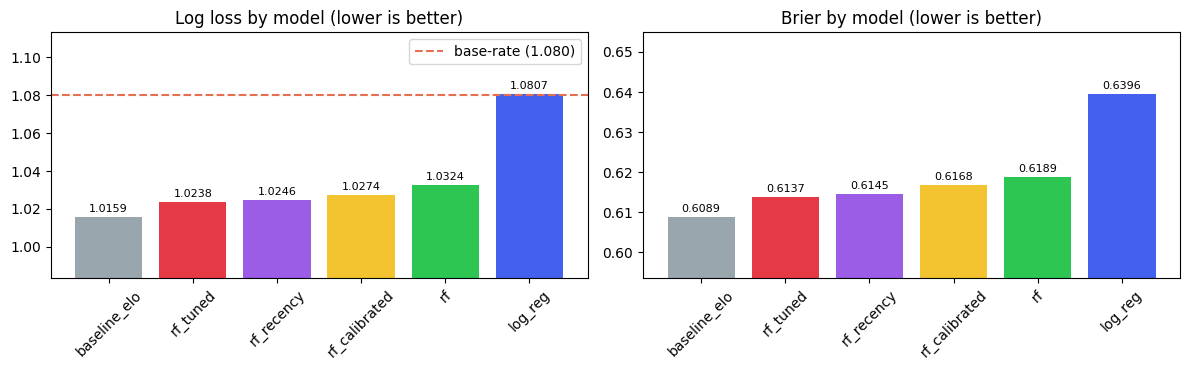

In [7]:
MODEL_COLOURS = {
    "baseline_elo":  "#9aa6ad",
    "rf_tuned":      "#e63946",
    "rf_recency":    "#9b5de5",
    "rf_calibrated": "#f4c430",
    "rf":            "#2dc653",
    "log_reg":       "#4361ee",
}

# Multiclass log loss + Brier for a model's prediction rows.
def multiclass_metrics(df):
    Pm = df[PROB_COLS].to_numpy()
    yi = df["y_true"].map(CLASS_IDX).to_numpy()
    ll = -np.mean(np.log(np.clip(Pm[np.arange(len(Pm)), yi], 1e-15, None)))
    onehot = np.zeros_like(Pm); onehot[np.arange(len(Pm)), yi] = 1.0
    brier = np.mean(np.sum((Pm - onehot) ** 2, axis=1))
    return ll, brier

summary = pd.DataFrame(
    [{"model": m, **dict(zip(["log_loss", "brier"], multiclass_metrics(model_frame(m))))}
     for m in MODELS]
).sort_values("log_loss").reset_index(drop=True)

# Reference floor: always predicting the class base rates.
d0 = model_frame(MODELS[0])
yi_all = d0["y_true"].map(CLASS_IDX).to_numpy()
base = np.bincount(yi_all, minlength=3) / len(yi_all)
base_ll = -np.mean(np.log(base[yi_all]))

print(summary.round(4).to_string(index=False))
print(f"\nbase-rate log loss: {base_ll:.4f}   uniform (1/3): {np.log(3):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, metric, title in zip(axes, ["log_loss", "brier"], ["Log loss", "Brier"]):
    s = summary.sort_values(metric)
    colours = [MODEL_COLOURS.get(m, "#9aa6ad") for m in s["model"]]
    bars = ax.bar(s["model"], s[metric], color=colours)

    ymin = s[metric].min()
    ymax = s[metric].max()
    margin = (ymax - ymin) * 0.5
    ax.set_ylim(ymin - margin, ymax + margin)

    for bar, val in zip(bars, s[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + margin * 0.05,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

    ax.set_title(f"{title} by model (lower is better)")
    ax.tick_params(axis="x", rotation=45)

axes[0].axhline(base_ll, color="#e76f51", ls="--", label=f"base-rate ({base_ll:.3f})")
axes[0].legend()
plt.tight_layout()
plt.show()

## 2. Classification — confusion matrix & precision / recall / F1

In [12]:
# Accuracy overview across models (+ draw recall and how many draws each model ever picks).
acc_rows = []
for m in MODELS:
    yt, P, yp = predictions(model_frame(m))
    acc_rows.append({
        "model": m,
        "accuracy": (yp == yt).mean(),
        "draw_recall": ((yp == "D") & (yt == "D")).sum() / max((yt == "D").sum(), 1),
        "draws_predicted": int((yp == "D").sum()),
    })
print(pd.DataFrame(acc_rows).round(4).to_string(index=False))
print(f"\nalways-home baseline accuracy: {(d0['y_true'] == 'HW').mean():.4f}")

        model  accuracy  draw_recall  draws_predicted
 baseline_elo    0.4987       0.0000                0
      log_reg    0.4921       0.1015               59
           rf    0.5013       0.0355               13
     rf_tuned    0.5132       0.0000                0
   rf_recency    0.5013       0.0051                1
rf_calibrated    0.5066       0.0000                0

always-home baseline accuracy: 0.4171


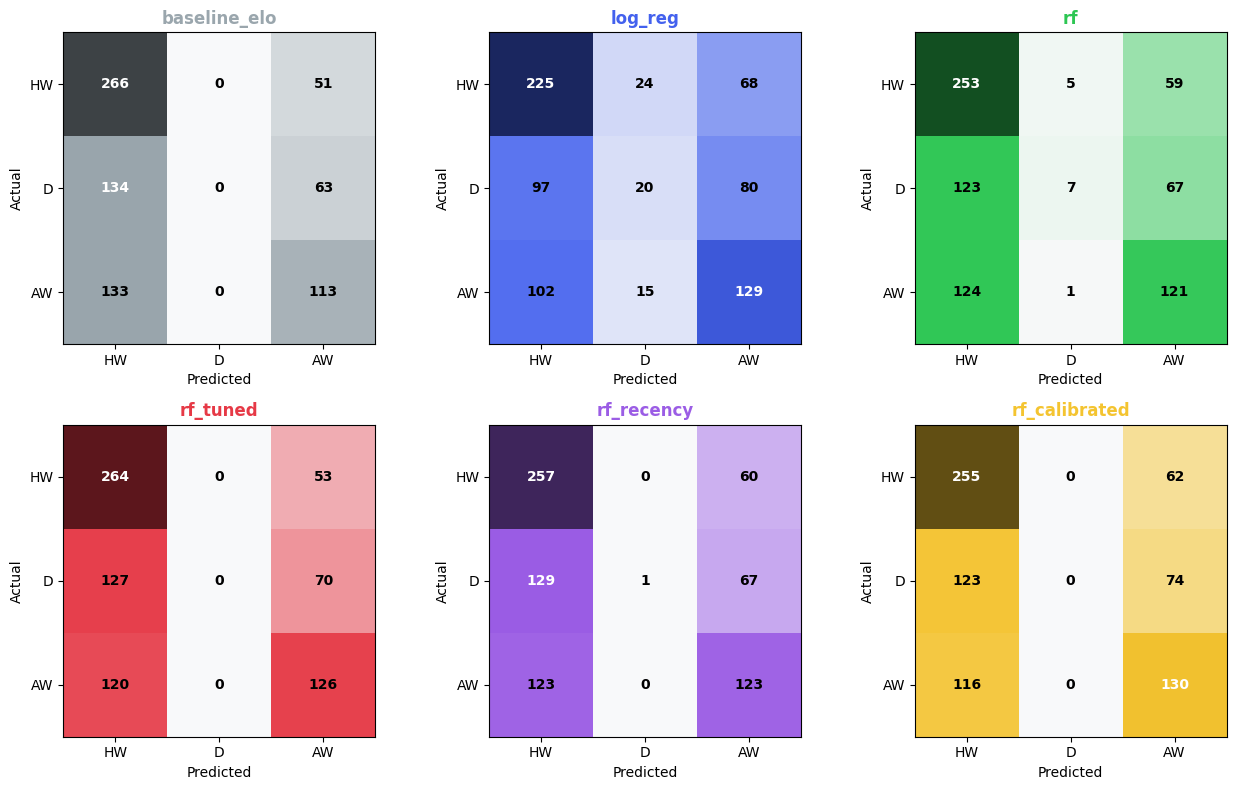

In [9]:
import matplotlib.colors as mcolors

def hex_to_dark_cmap(hex_colour):
    """Create a colormap from white to a dark version of the model colour."""
    base = mcolors.to_rgb(hex_colour)
    # dark version = scale down by 40%
    dark = tuple(c * 0.4 for c in base)
    return mcolors.LinearSegmentedColormap.from_list("", ["#f8f9fa", hex_colour, dark])

# Confusion matrix per model.
ncols = 3
nrows = int(np.ceil(len(MODELS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))

for ax, m in zip(axes.ravel(), MODELS):
    yt, P, yp = predictions(model_frame(m))
    cm = confusion_matrix(yt, yp, labels=LABEL_ORDER)
    
    cmap = hex_to_dark_cmap(MODEL_COLOURS.get(m, "#9aa6ad"))
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=cm.max())
    
    ax.set_xticks(range(3)); ax.set_xticklabels(LABEL_ORDER)
    ax.set_yticks(range(3)); ax.set_yticklabels(LABEL_ORDER)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(m, color=MODEL_COLOURS.get(m, "#9aa6ad"), fontweight="bold")
    
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black",
                    fontweight="bold")

for ax in axes.ravel()[len(MODELS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Per-class precision / recall / F1 / accuracy for every model.
for m in MODELS:
    yt, P, yp = predictions(model_frame(m))
    print(f"===== {m} =====")
    print(classification_report(
        yt, yp, labels=LABEL_ORDER,
        target_names=[LABEL_NAMES[l] for l in LABEL_ORDER], zero_division=0,
    ))

===== baseline_elo =====
              precision    recall  f1-score   support

    Home win       0.50      0.84      0.63       317
        Draw       0.00      0.00      0.00       197
    Away win       0.50      0.46      0.48       246

    accuracy                           0.50       760
   macro avg       0.33      0.43      0.37       760
weighted avg       0.37      0.50      0.42       760

===== log_reg =====
              precision    recall  f1-score   support

    Home win       0.53      0.71      0.61       317
        Draw       0.34      0.10      0.16       197
    Away win       0.47      0.52      0.49       246

    accuracy                           0.49       760
   macro avg       0.45      0.45      0.42       760
weighted avg       0.46      0.49      0.45       760

===== rf =====
              precision    recall  f1-score   support

    Home win       0.51      0.80      0.62       317
        Draw       0.54      0.04      0.07       197
    Away win   

## 3. Reliability (calibration)

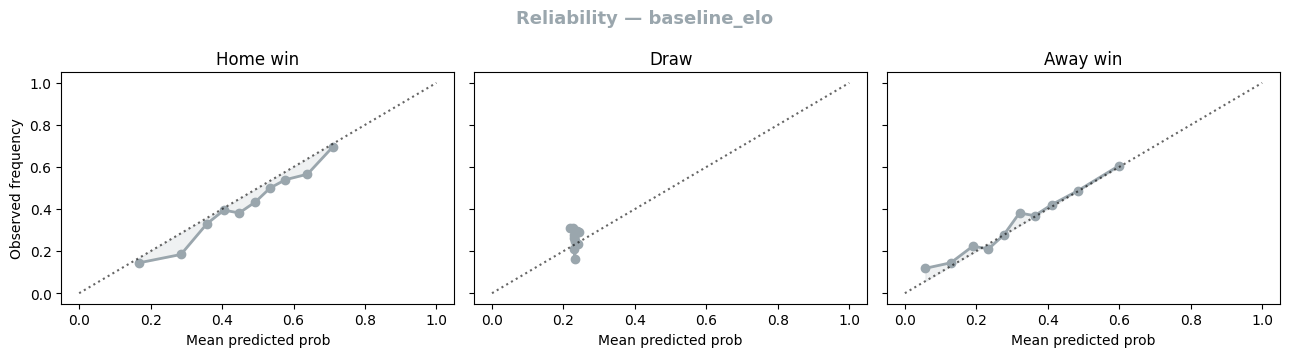

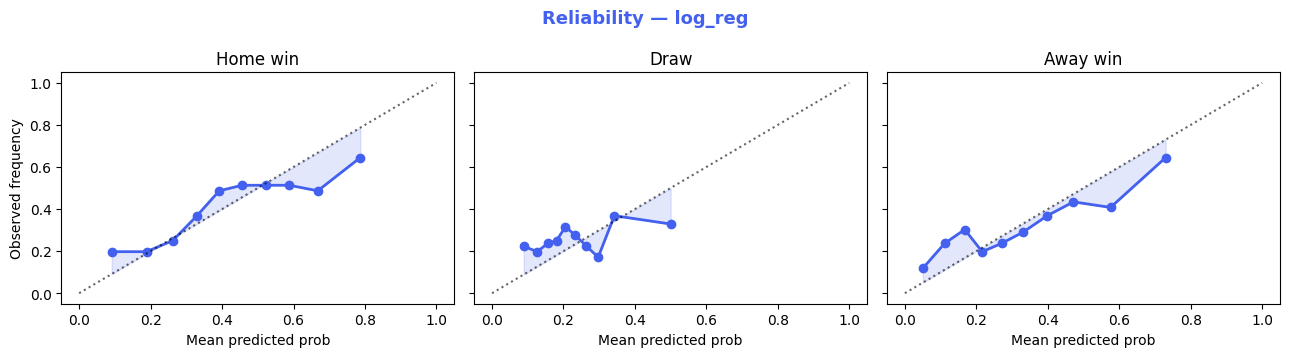

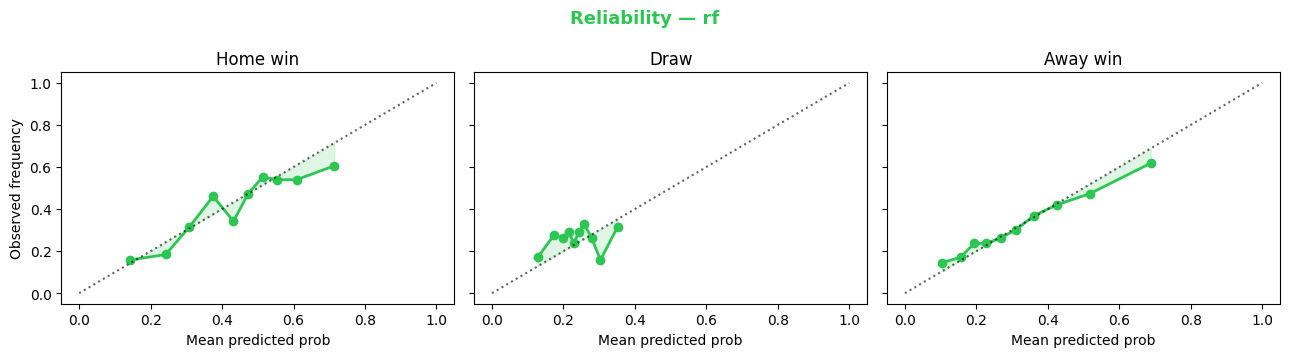

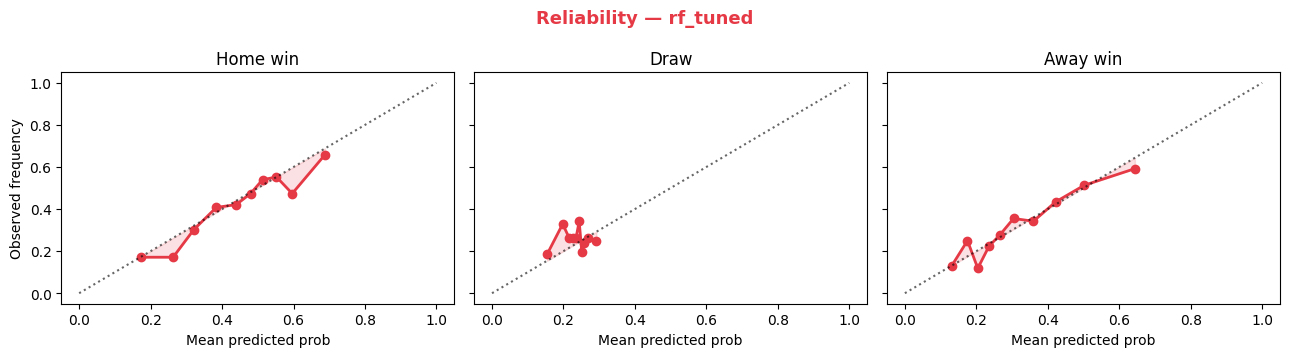

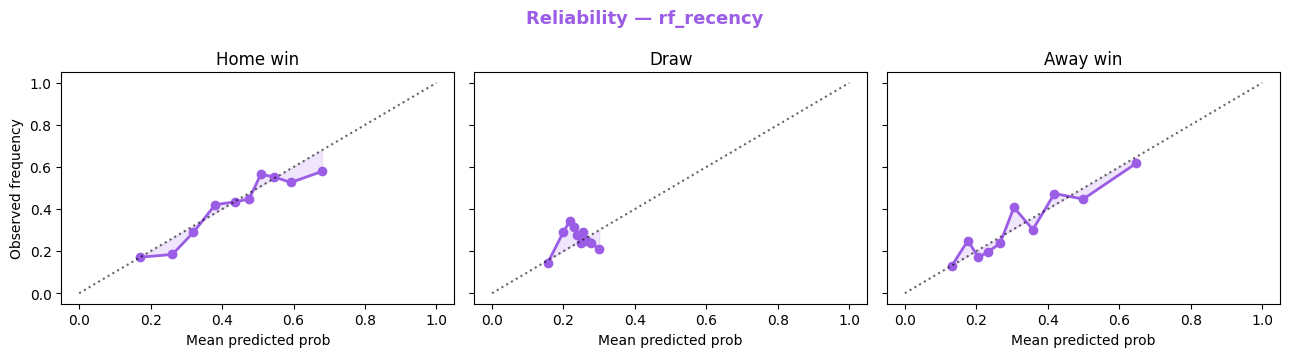

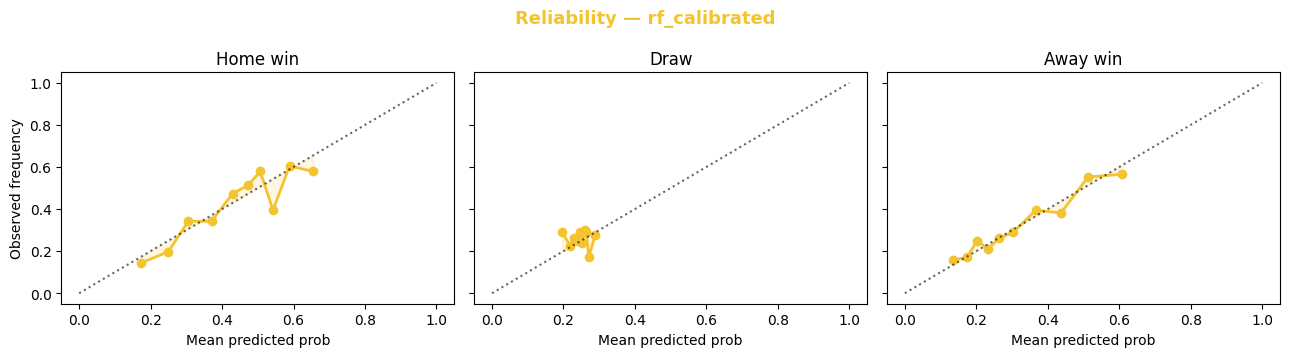

In [11]:
# Per-outcome (one-vs-rest) reliability for each model; points on the diagonal = calibrated.
for m in MODELS:
    dm = model_frame(m)
    model_colour = MODEL_COLOURS.get(m, "#9aa6ad")
    
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for ax, label, col in zip(axes, LABEL_ORDER, PROB_COLS):
        y_bin = (dm["y_true"] == label).astype(int).to_numpy()
        frac_pos, mean_pred = calibration_curve(
            y_bin, dm[col].to_numpy(), n_bins=10, strategy="quantile"
        )
        ax.plot(mean_pred, frac_pos, "o-", color=model_colour, lw=2, ms=6)
        ax.plot([0, 1], [0, 1], "k:", alpha=0.6)
        ax.set_title(LABEL_NAMES[label])
        ax.set_xlabel("Mean predicted prob")
        # shade the area between the curve and diagonal
        ax.fill_between(mean_pred, frac_pos, mean_pred,
                        alpha=0.15, color=model_colour)

    axes[0].set_ylabel("Observed frequency")
    fig.suptitle(f"Reliability — {m}", color=model_colour, fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()